# Ferric / dust (OMEGA) — crop & null fill

Layer key: `ferric`  
File: `omega_ferric_nnphs.tif`  
Path: `/Users/eshaankhare/Downloads/Mars Geoscience/omega_ferric_nnphs.tif`

Null rule: value == 0, non-finite, or GDAL nodata tag.

Scan (/Users/eshaankhare/Downloads/Mars Geoscience): **14.59%** exact zeros (122,766 px) — HAS missing zeros. nodata_tag=None, size 1119×752, valid nonzero range 0.8349 .. 1.039.

Exact zeros ~14.6% — OMEGA coverage gaps (good fill candidate). Real ferric usually ~0.9–1.1.

1. Run config + helpers  
2. Preview full layer (grey = null)  
3. Pick / adjust `CROP_LATLON`  
4. Fill + compare  

Fill methods: `idw_gaussian` (default), `idw`, `median`, `nearest`


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import from_bounds, rowcol, xy
from rasterio.windows import Window
from scipy.ndimage import binary_dilation, distance_transform_edt, gaussian_filter
from scipy.spatial import cKDTree


In [2]:
TIF_PATH = Path("/Users/eshaankhare/Downloads/Mars Geoscience/omega_ferric_nnphs.tif")
BAND = 1
CROP_PIXELS = None

# southern streak (~56%)
CROP_LATLON = dict(lat_min=-56, lat_max=-51, lon_min=128, lon_max=133)
# mid-lat streak (~70%)
# CROP_LATLON = dict(lat_min=20, lat_max=25, lon_min=163, lon_max=173)
# high-lat streak (~80%)
# CROP_LATLON = dict(lat_min=68, lat_max=73, lon_min=100, lon_max=110)
# north polar edge (~39%)
# CROP_LATLON = dict(lat_min=85, lat_max=90, lon_min=100, lon_max=140)

FILL_METHOD = "idw_gaussian"
K_NEIGHBORS = 24
GAUSS_SIGMA = 6
FEATHER_PX = 4
NODATA = None  # set from file when opened


In [3]:
def mars_transform(width, height):
    return from_bounds(-180, -90, 180, 90, width, height)


def raster_transform(src):
    if src.crs is None and src.transform == rasterio.Affine.identity():
        return mars_transform(src.width, src.height), True
    return src.transform, False


def null_mask(data, nodata=None):
    # zeros + non-finite + GDAL nodata tag (if present) all count as missing
    bad = (data == 0) | ~np.isfinite(data)
    if nodata is not None:
        try:
            nd = float(nodata)
            if np.isfinite(nd):
                bad |= data == nd
        except (TypeError, ValueError):
            pass
    return bad


def latlon_to_window(transform, height, width, crop):
    r0, c0 = rowcol(transform, crop["lon_min"], crop["lat_max"])
    r1, c1 = rowcol(transform, crop["lon_max"], crop["lat_min"])
    row_off = max(0, min(r0, r1))
    col_off = max(0, min(c0, c1))
    row_end = min(height, max(r0, r1) + 1)
    col_end = min(width, max(c0, c1) + 1)
    return Window(col_off, row_off, col_end - col_off, row_end - row_off)


def pixels_to_window(crop):
    return Window(crop["col_off"], crop["row_off"], crop["width"], crop["height"])


def read_band(path, band, window, transform):
    with rasterio.open(path) as src:
        data = src.read(band, window=window).astype(np.float32)
        nodata = src.nodata
    subtransform = rasterio.windows.transform(window, transform)
    return data, subtransform, nodata


def read_preview(path, band, transform, max_side=1200):
    with rasterio.open(path) as src:
        step = max(1, int(np.ceil(max(src.height, src.width) / max_side)))
        out_h = int(np.ceil(src.height / step))
        out_w = int(np.ceil(src.width / step))
        data = src.read(band, out_shape=(out_h, out_w), resampling=Resampling.average)
        nodata = src.nodata
        width, height = src.width, src.height
    # Always report geographic bounds for the full raster (preview is just a downsample).
    bounds = rasterio.coords.BoundingBox(-180, -90, 180, 90)
    try:
        left, bottom, right, top = rasterio.transform.array_bounds(height, width, transform)
        bounds = rasterio.coords.BoundingBox(left, bottom, right, top)
    except Exception:
        pass
    return data, bounds, nodata


def display_data(data, nodata=None, vmin=None, vmax=None):
    out = data.astype(np.float64, copy=True)
    out[null_mask(out, nodata)] = np.nan
    valid = np.isfinite(out)
    if vmin is None and valid.any():
        vmin = float(np.nanpercentile(out, 2))
    if vmax is None and valid.any():
        vmax = float(np.nanpercentile(out, 98))
    return out, vmin, vmax


def show_raster(data, bounds, title="", nodata=None, vmin=None, vmax=None):
    disp, vmin, vmax = display_data(data, nodata, vmin, vmax)
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(disp, cmap="viridis", origin="upper", extent=extent, vmin=vmin, vmax=vmax)
    ax.set_xlabel("longitude (°E)")
    ax.set_ylabel("latitude (°N)")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.03, label="value (grey = null/zero)")
    plt.tight_layout()
    plt.show()


def crop_latlon_bounds(full_transform, window):
    # full_transform = whole-raster affine; window = crop in that raster.
    # Do NOT pass a window-local transform here or lat/lon gets double-shifted.
    rows = [window.row_off, window.row_off + window.height - 1]
    cols = [window.col_off, window.col_off + window.width - 1]
    lons, lats = [], []
    for r in rows:
        for c in cols:
            x, y = xy(full_transform, r, c)
            lons.append(x)
            lats.append(y)
    return dict(lat_min=min(lats), lat_max=max(lats), lon_min=min(lons), lon_max=max(lons))


In [4]:
def idw_fill(data, bad, k_neighbors=12):
    out = data.astype(np.float64, copy=True)
    if not bad.any():
        return out.astype(data.dtype)

    valid = ~bad
    fringe = valid & binary_dilation(bad, iterations=3)
    rs, cs = np.where(fringe if fringe.any() else valid)
    tree = cKDTree(np.column_stack([rs, cs]).astype(np.float64))
    values = out[rs, cs]

    qr, qc = np.where(bad)
    dists, idxs = tree.query(
        np.column_stack([qr, qc]).astype(np.float64),
        k=min(k_neighbors, len(values)),
    )
    if dists.ndim == 1:
        dists, idxs = dists[:, None], idxs[:, None]
    w = 1.0 / np.maximum(dists, 1e-6) ** 2
    out[qr, qc] = (w * values[idxs]).sum(axis=1) / w.sum(axis=1)
    return out.astype(data.dtype)


def gaussian_blend(data, bad, sigma=6.0, feather_px=40):
    smoothed = gaussian_filter(data.astype(np.float64), sigma=sigma, mode="nearest")
    dist_out = distance_transform_edt(~bad)
    alpha = np.zeros(data.shape, dtype=np.float64)
    alpha[bad] = 1.0
    edge = (~bad) & (dist_out <= feather_px)
    alpha[edge] = 1.0 - dist_out[edge] / feather_px
    out = alpha * smoothed + (1.0 - alpha) * data.astype(np.float64)
    return out.astype(data.dtype)


def nearest_fill(data, bad):
    out = data.copy()
    _, idx = distance_transform_edt(bad, return_distances=True, return_indices=True)
    out[bad] = data[idx[0][bad], idx[1][bad]]
    return out


def median_fill(data, bad, radius=15):
    out = data.astype(np.float64, copy=True)
    out[bad] = np.nan
    yy, xx = np.mgrid[-radius : radius + 1, -radius : radius + 1]
    disk = (yy * yy + xx * xx) <= radius * radius
    oy, ox = yy[disk], xx[disk]
    padded = np.pad(out, radius, constant_values=np.nan)
    br, bc = np.where(bad)
    patches = padded[br[:, None] + radius + oy, bc[:, None] + radius + ox]
    out[br, bc] = np.nanmedian(patches, axis=1)
    return out.astype(data.dtype)


def fill_nulls(data, method="idw_gaussian", nodata=None, **kwargs):
    bad = null_mask(data, nodata)
    if not bad.any():
        print("WARNING: no null/zero pixels in this crop")
        return data.copy(), bad

    if method == "idw":
        filled = idw_fill(data, bad, kwargs.get("k_neighbors", 12))
    elif method == "idw_gaussian":
        filled = idw_fill(data, bad, kwargs.get("k_neighbors", 12))
        filled = gaussian_blend(filled, bad, kwargs.get("gauss_sigma", 6.0), kwargs.get("feather_px", 40))
    elif method == "median":
        filled = median_fill(data, bad)
    elif method == "nearest":
        filled = nearest_fill(data, bad)
    else:
        raise ValueError(f"unknown method: {method!r}")

    # keep filled holes from remaining as literal zero
    filled = filled.copy()
    filled[bad] = np.where(filled[bad] == 0, 1e-6, filled[bad])
    return filled, bad


file: /Users/eshaankhare/Downloads/Mars Geoscience/omega_ferric_nnphs.tif
size: 1119 x 752 px
nodata tag: None
georef: none — assuming global Mars (-180..180, -90..90)
null/zero (preview): 14.6%


/Users/eshaankhare/gitrepo/VANGUARD/.venv/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


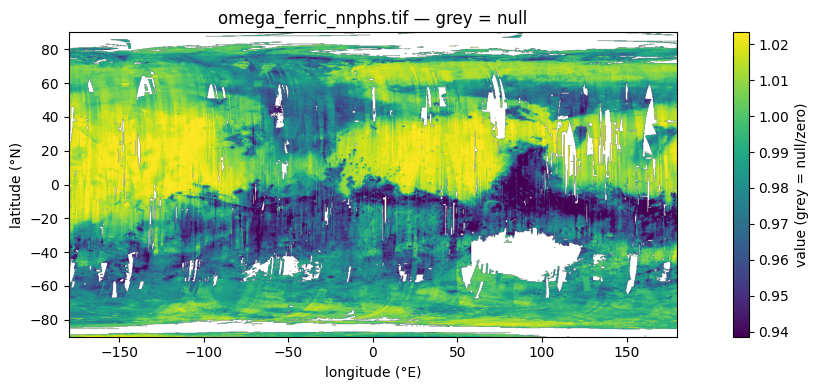

In [5]:
with rasterio.open(TIF_PATH) as src:
    transform, assumed_georef = raster_transform(src)
    width, height = src.width, src.height
    NODATA = src.nodata
    full_bounds = rasterio.coords.BoundingBox(-180, -90, 180, 90)
    if not assumed_georef:
        full_bounds = src.bounds

preview, _, _ = read_preview(TIF_PATH, BAND, transform)
preview_null_pct = 100 * null_mask(preview, NODATA).mean()

print(f"file: {TIF_PATH}")
print(f"size: {width} x {height} px")
print(f"nodata tag: {NODATA}")
if assumed_georef:
    print("georef: none — assuming global Mars (-180..180, -90..90)")
print(f"null/zero (preview): {preview_null_pct:.1f}%")

show_raster(preview, full_bounds, title=f"{TIF_PATH.name} — grey = null", nodata=NODATA)


crop lat: -55.89 .. -51.10
crop lon: 128.04 .. 132.87
shape: 16 x 21 px
null/zero: 82 (24.4%)


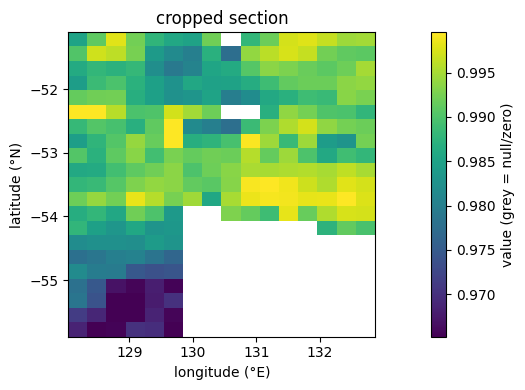

In [6]:
with rasterio.open(TIF_PATH) as src:
    transform, _ = raster_transform(src)
    NODATA = src.nodata
    if CROP_PIXELS is not None:
        window = pixels_to_window(CROP_PIXELS)
    elif CROP_LATLON is not None:
        window = latlon_to_window(transform, src.height, src.width, CROP_LATLON)
    else:
        raise ValueError("Set CROP_LATLON or CROP_PIXELS")

    raw, crop_transform, NODATA = read_band(TIF_PATH, BAND, window, transform)
    actual = crop_latlon_bounds(transform, window)

bad = null_mask(raw, NODATA)
crop_bounds = rasterio.coords.BoundingBox(
    actual["lon_min"], actual["lat_min"], actual["lon_max"], actual["lat_max"]
)

print(f"crop lat: {actual['lat_min']:.2f} .. {actual['lat_max']:.2f}")
print(f"crop lon: {actual['lon_min']:.2f} .. {actual['lon_max']:.2f}")
print(f"shape: {raw.shape[1]} x {raw.shape[0]} px")
print(f"null/zero: {int(bad.sum()):,} ({100 * bad.mean():.1f}%)")

show_raster(raw, crop_bounds, title="cropped section", nodata=NODATA)


In [7]:
filled, bad = fill_nulls(
    raw,
    FILL_METHOD,
    nodata=NODATA,
    k_neighbors=K_NEIGHBORS,
    gauss_sigma=GAUSS_SIGMA,
    feather_px=FEATHER_PX,
)

remaining = int(null_mask(filled, NODATA).sum())
print(f"method: {FILL_METHOD}")
print(f"null before: {int(bad.sum()):,}  after: {remaining}")
if bad.any():
    print(f"filled range: {filled[bad].min():.4f} .. {filled[bad].max():.4f}")


method: idw_gaussian
null before: 82  after: 0
filled range: 0.9773 .. 0.9906


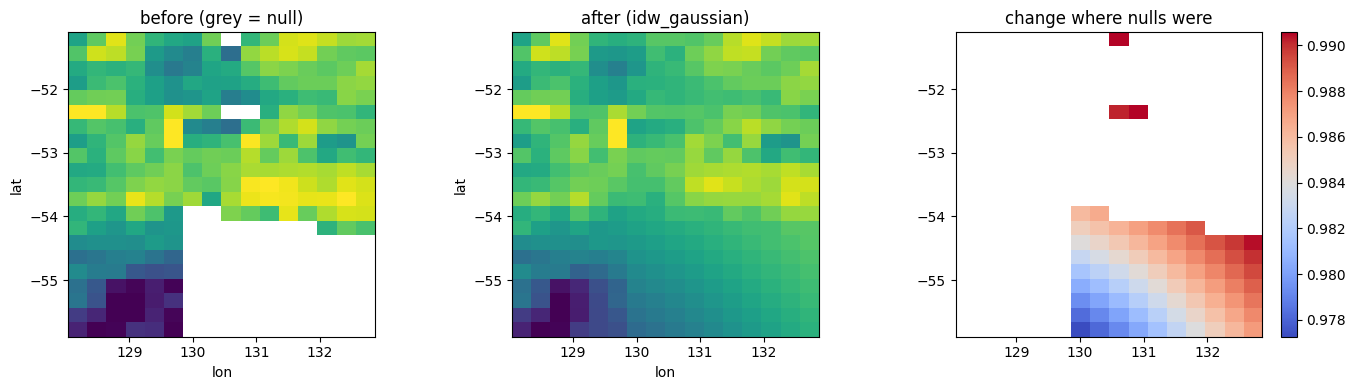

In [8]:
before, vmin, vmax = display_data(raw, NODATA)
after, _, _ = display_data(filled, NODATA, vmin=vmin, vmax=vmax)
extent = [crop_bounds.left, crop_bounds.right, crop_bounds.bottom, crop_bounds.top]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(before, cmap="viridis", origin="upper", extent=extent, vmin=vmin, vmax=vmax)
axes[0].set_title("before (grey = null)")
axes[1].imshow(after, cmap="viridis", origin="upper", extent=extent, vmin=vmin, vmax=vmax)
axes[1].set_title(f"after ({FILL_METHOD})")
diff = np.where(bad, filled - raw, np.nan)
im = axes[2].imshow(diff, cmap="coolwarm", origin="upper", extent=extent)
axes[2].set_title("change where nulls were")
plt.colorbar(im, ax=axes[2], fraction=0.046)
for ax in axes[:2]:
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
plt.tight_layout()
plt.show()


In [9]:
# save filled crop + before/after plot next to this notebook
out_dir = Path(".").resolve()
stem = TIF_PATH.stem
out_tif = out_dir / f"{stem}_filled_crop.tif"
out_png = out_dir / f"{stem}_before_after.png"

profile = {
    "driver": "GTiff",
    "height": filled.shape[0],
    "width": filled.shape[1],
    "count": 1,
    "dtype": "float32",
    "crs": "EPSG:4326",
    "transform": crop_transform,
    "compress": "deflate",
}
with rasterio.open(out_tif, "w", **profile) as dst:
    dst.write(filled.astype("float32"), 1)

before, vmin, vmax = display_data(raw, NODATA)
after, _, _ = display_data(filled, NODATA, vmin=vmin, vmax=vmax)
extent = [crop_bounds.left, crop_bounds.right, crop_bounds.bottom, crop_bounds.top]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(before, cmap="viridis", origin="upper", extent=extent, vmin=vmin, vmax=vmax)
axes[0].set_title("before (grey = null)")
axes[1].imshow(after, cmap="viridis", origin="upper", extent=extent, vmin=vmin, vmax=vmax)
axes[1].set_title(f"after ({FILL_METHOD})")
diff = np.where(bad, filled - raw, np.nan)
im = axes[2].imshow(diff, cmap="coolwarm", origin="upper", extent=extent)
axes[2].set_title("change where nulls were")
plt.colorbar(im, ax=axes[2], fraction=0.046)
for ax in axes[:2]:
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
plt.tight_layout()
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"wrote {out_tif}")
print(f"wrote {out_png}")


wrote /Users/eshaankhare/gitrepo/VANGUARD/backend/notebooks/gap_fills/omega_ferric_nnphs_filled_crop.tif
wrote /Users/eshaankhare/gitrepo/VANGUARD/backend/notebooks/gap_fills/omega_ferric_nnphs_before_after.png
